# Decision Tree Regressor (Simple Explanation)

A **Decision Tree** is like a flowchart of questions.
- It asks questions about features (for example: `R&D Spend <= 120000?`).
- Each answer sends data to the next branch.
- At the end, a leaf gives the final prediction.

For **regression**, the final output is a number (like profit).

In simple English: a decision tree breaks a big problem into many small yes/no decisions until it can predict a value.

## Step 1: Import Libraries

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Step 2: Load Dataset
We use `50_Startups.csv`. Target column is `Profit`.

In [3]:
df = pd.read_csv('50_Startups.csv')
print('Shape:', df.shape)
display(df.head())
print('\nMissing values:')
print(df.isnull().sum())

Shape: (50, 5)


,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94



Missing values:
R&D Spend          2
Administration     2
Marketing Spend    3
State              3
Profit             0
dtype: int64


## Step 3: Separate Features and Target
- `X` = input columns
- `y` = output column (`Profit`)

In [4]:
X = df.drop('Profit', axis=1)
y = df['Profit']

num_features = X.select_dtypes(include=['number']).columns
cat_features = X.select_dtypes(exclude=['number']).columns

print('Numeric columns:', list(num_features))
print('Categorical columns:', list(cat_features))

Numeric columns: ['R&D Spend', 'Administration', 'Marketing Spend']
Categorical columns: ['State']


## Step 4: Preprocessing + Pipeline
Why pipeline?
- Keeps preprocessing and model together
- Avoids mistakes and data leakage
- Easier to reuse

In [25]:
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, num_features),
    ('cat', categorical_pipeline, cat_features)
])

model = DecisionTreeRegressor(max_depth=5, random_state=42)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

## Step 5: Train-Test Split, Train Model, Predict

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print('Training samples:', X_train.shape[0])
print('Testing samples:', X_test.shape[0])

Training samples: 40
Testing samples: 10


## Step 6: Important Scores
- **MAE**: average absolute error (lower is better)
- **RMSE**: bigger errors are penalized more (lower is better)
- **R2 Score**: how well model explains target variance (closer to 1 is better)

In [27]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

scores_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2'],
    'Value': [mae, rmse, r2]
})

display(scores_df)
print(f'MAE:  {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R2:   {r2:.4f}')

,Metric,Value
0,MAE,10433.818750
1,RMSE,12341.235914
2,R2,0.811919


MAE:  10433.82
RMSE: 12341.24
R2:   0.8119


## Step 7: Graphs for Model Performance

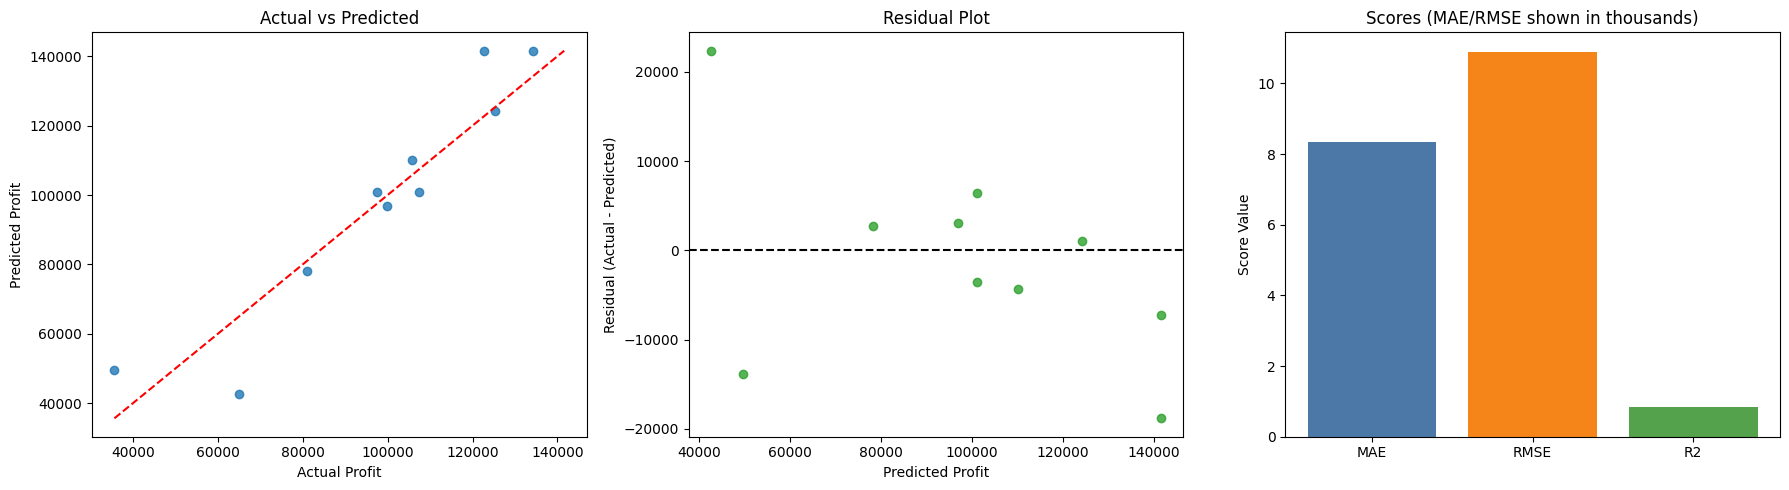

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Actual vs Predicted
axes[0].scatter(y_test, y_pred, color='tab:blue', alpha=0.8)
line_min = min(y_test.min(), y_pred.min())
line_max = max(y_test.max(), y_pred.max())
axes[0].plot([line_min, line_max], [line_min, line_max], 'r--')
axes[0].set_title('Actual vs Predicted')
axes[0].set_xlabel('Actual Profit')
axes[0].set_ylabel('Predicted Profit')

# 2) Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, color='tab:green', alpha=0.8)
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title('Residual Plot')
axes[1].set_xlabel('Predicted Profit')
axes[1].set_ylabel('Residual (Actual - Predicted)')

# 3) Important score graph
plot_scores = scores_df.copy()
plot_scores.loc[plot_scores['Metric'].isin(['MAE', 'RMSE']), 'Value'] = \
    plot_scores.loc[plot_scores['Metric'].isin(['MAE', 'RMSE']), 'Value'] / 1000

axes[2].bar(plot_scores['Metric'], plot_scores['Value'], color=['#4c78a8', '#f58518', '#54a24b'])
axes[2].set_title('Scores (MAE/RMSE shown in thousands)')
axes[2].set_ylabel('Score Value')

plt.tight_layout()
plt.show()

## Step 8: Feature Importance (What Influences Prediction Most)

,Feature,Importance
0,num__R&D Spend,0.880908
2,num__Marketing Spend,0.113855
1,num__Administration,0.004631
3,cat__State_California,0.000606
4,cat__State_Florida,0.000000
5,cat__State_New York,0.000000


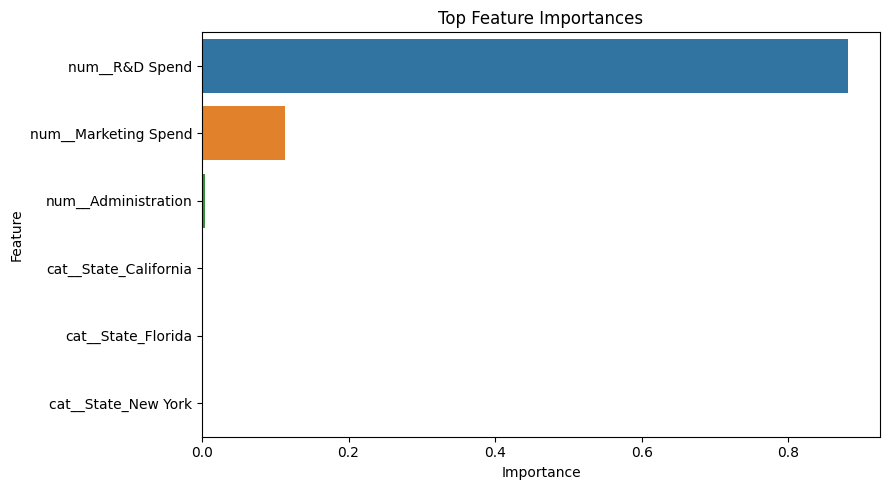

In [21]:
trained_tree = pipeline.named_steps['model']
trained_preprocessor = pipeline.named_steps['preprocessor']

feature_names = trained_preprocessor.get_feature_names_out()
importances = trained_tree.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

display(importance_df.head(10))

plt.figure(figsize=(9, 5))
top_n = 10
sns.barplot(
    data=importance_df.head(top_n),
    x='Importance', y='Feature',
    hue='Feature',
    dodge=False,
    legend=False
)
plt.title('Top Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Step 9: Plot the Decision Tree

Yes, we can plot a Decision Tree Regressor.

Note:
- A full tree can become very large and hard to read.
- So we use `max_depth=3` in the plot to show only top levels clearly.

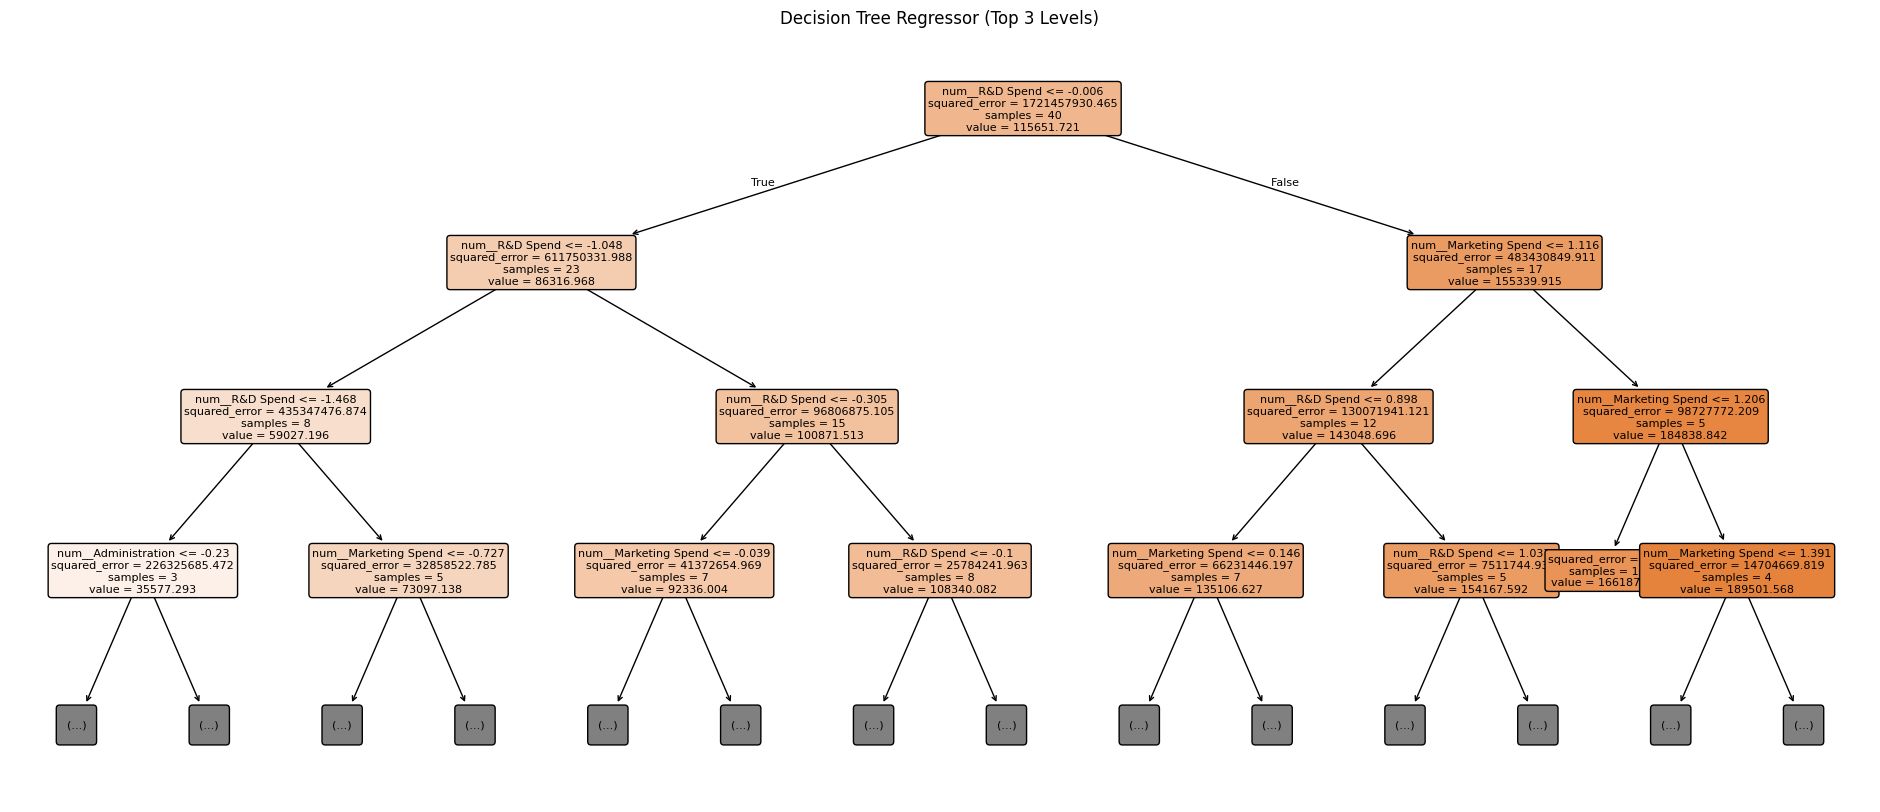

In [28]:
from sklearn.tree import plot_tree

trained_tree = pipeline.named_steps['model']
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

plt.figure(figsize=(24, 10))
plot_tree(
    trained_tree,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title('Decision Tree Regressor (Top 3 Levels)')
plt.show()

## Simple English Summary
- Decision Tree learned rules from startup data.
- Preprocessing handled missing values and category encoding.
- Scores (MAE, RMSE, R2) show how good predictions are.
- Graphs help you understand prediction quality and errors visually.